In [1]:
# Name: Dhruv Kumar
# Roll No.: 24419CMP011
# Course: M.Sc. Computer Science
# Semester: 2nd

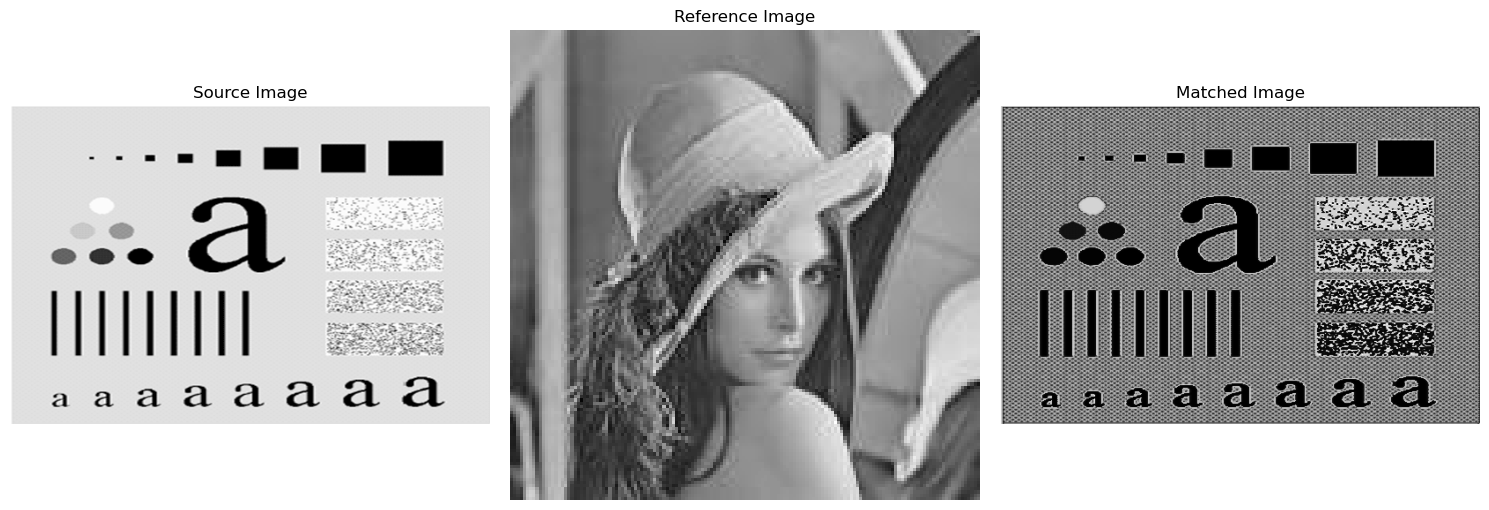

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def histogram_cdf(image):
    hist = [0] * 256
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            hist[image[i, j]] += 1
    
    num_pixels = rows * cols
    pdf = [h / num_pixels for h in hist]

    cdf = [0] * 256
    c = 0
    for i in range(256):
        c += pdf[i]
        cdf[i] = c

    return cdf

def histogram_matching(source, reference):
    
    # Compute CDFs manually
    cdf_src = histogram_cdf(source)
    cdf_ref = histogram_cdf(reference)

    # Create mapping from source to reference
    mapping = [0] * 256
    for i in range(256):
        diff = float('inf')
        ref_val = 0
        for j in range(256):
            if abs(cdf_src[i] - cdf_ref[j]) < diff:
                diff = abs(cdf_src[i] - cdf_ref[j])
                ref_val = j
        mapping[i] = ref_val

    # Apply mapping
    rows, cols = source.shape
    matched = np.zeros_like(source)
    for i in range(rows):
        for j in range(cols):
            matched[i, j] = mapping[source[i, j]]

    return matched

source = cv2.imread("D:\\Code\\test_img.png", cv2.IMREAD_GRAYSCALE)
reference = cv2.imread("D:\\Code\\Lenna.jpeg", cv2.IMREAD_GRAYSCALE)

matched = histogram_matching(source, reference)

# Display
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(source, cmap='gray')
plt.title("Source Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reference, cmap='gray')
plt.title("Reference Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched, cmap='gray')
plt.title("Matched Image")
plt.axis('off')

plt.tight_layout()
plt.show()

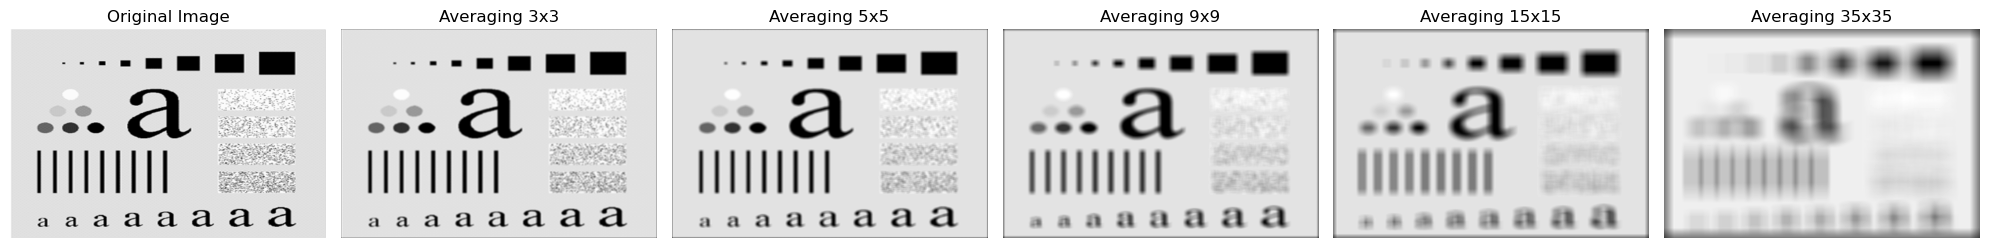

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_averaging_filter(image, size):
    pad = size // 2
    rows, cols = image.shape

    # Pad the image with zeros
    padded_img = np.zeros((rows + 2 * pad, cols + 2 * pad))
    padded_img[pad:pad+rows, pad:pad+cols] = image

    # Create output image
    output = np.zeros_like(image)

    # Apply the mean filter
    for i in range(rows):
        for j in range(cols):
            window = padded_img[i:i + size, j:j + size]
            output[i, j] = np.sum(window) // (size * size)
    return output

def main():
    img = cv2.imread('D:\\Code\\test_img.png', cv2.IMREAD_GRAYSCALE)

    filter_sizes = [3, 5, 9, 15, 35]
    smoothed_images = []

    for size in filter_sizes:
        blurred = apply_averaging_filter(img, size)
        smoothed_images.append(blurred)

    # Plot original and filtered images
    plt.figure(figsize=(20, 5))

    # Plot original image
    plt.subplot(1, 6, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # Plot filtered images
    for i in range(len(filter_sizes)):
        plt.subplot(1, 6, i + 2)
        plt.imshow(smoothed_images[i], cmap='gray')
        plt.title(f'Averaging {filter_sizes[i]}x{filter_sizes[i]}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

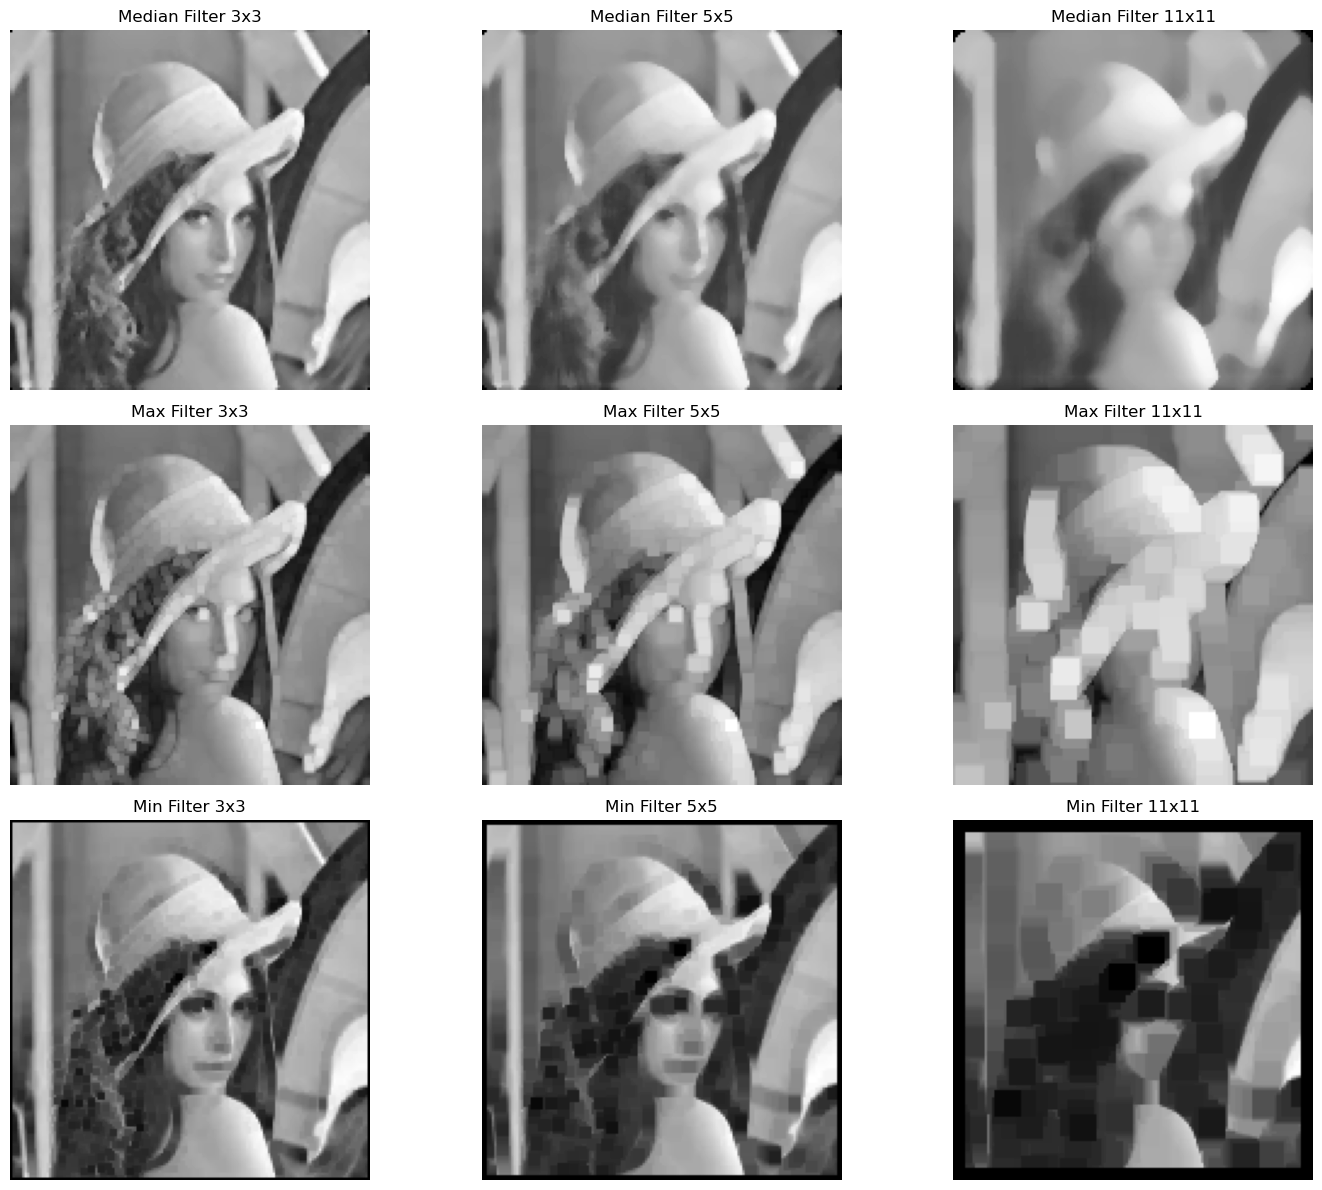

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_filter(image, size, filter_type):
    pad = size // 2
    rows, cols = image.shape
    
    padded_img = np.zeros((rows + 2 * pad, cols + 2 * pad))
    padded_img[pad:pad+rows, pad:pad+cols] = image
    
    output = np.zeros_like(image)

    for i in range(rows):
        for j in range(cols):
            window = padded_img[i:i+size, j:j+size].flatten()

            if filter_type == 'median':
                output[i, j] = np.median(window)
            elif filter_type == 'max':
                output[i, j] = np.max(window)
            elif filter_type == 'min':
                output[i, j] = np.min(window)

    return output

image = cv2.imread('D:\\Code\\lenna.jpeg', cv2.IMREAD_GRAYSCALE)
filter_sizes = [3, 5, 11]

# Precompute
median_filtered_images = []
max_filtered_images = []
min_filtered_images = []

for i in range(len(filter_sizes)):
    size = filter_sizes[i]
    median_filtered_images.append(apply_filter(image, size, 'median'))
    max_filtered_images.append(apply_filter(image, size, 'max'))
    min_filtered_images.append(apply_filter(image, size, 'min'))

# Plotting
fig, axes = plt.subplots(3, len(filter_sizes), figsize=(15, 12))

for i in range(len(filter_sizes)):
    axes[0, i].imshow(median_filtered_images[i], cmap='gray')
    axes[0, i].set_title(f'Median Filter {filter_sizes[i]}x{filter_sizes[i]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(max_filtered_images[i], cmap='gray')
    axes[1, i].set_title(f'Max Filter {filter_sizes[i]}x{filter_sizes[i]}')
    axes[1, i].axis('off')

    axes[2, i].imshow(min_filtered_images[i], cmap='gray')
    axes[2, i].set_title(f'Min Filter {filter_sizes[i]}x{filter_sizes[i]}')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

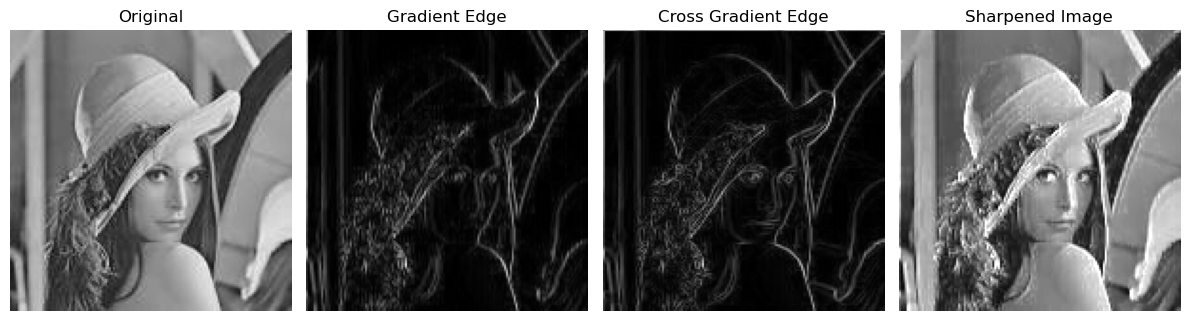

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_mask(image, mask):
    rows, cols = image.shape
    m_rows, m_cols = mask.shape
    pad_r, pad_c = m_rows // 2, m_cols // 2

    padded = np.zeros((rows + 2 * pad_r, cols + 2 * pad_c))
    padded[pad_r:pad_r + rows, pad_c:pad_c + cols] = image

    output = np.zeros_like(image)

    for i in range(rows):
        for j in range(cols):
            window = padded[i:i + m_rows, j:j + m_cols]
            output[i, j] = np.sum(window * mask)

    return output

def compute_gradient_magnitude(gx, gy):
    return np.sqrt(gx**2 + gy**2)

def unsharp_mask(original, edge_image, alpha=1.0):
    sharpened = original + alpha * edge_image
    sharpened = np.clip(sharpened, 0, 255)
    return sharpened

def main():
    # Load grayscale image and convert to float32
    image = cv2.imread("D:\\Code\\lenna.jpeg", cv2.IMREAD_GRAYSCALE).astype(np.float32)

    # 2x2 Gradient masks
    grad_x = np.array([[1, -1], [0, 0]])
    grad_y = np.array([[0, 0], [1, -1]])

    # 2x2 Cross-gradient masks
    cross_x = np.array([[1, 0], [0, -1]])
    cross_y = np.array([[0, -1], [1, 0]])

    # Apply gradient masks
    gx = apply_mask(image, grad_x)
    gy = apply_mask(image, grad_y)
    gradient_mag = compute_gradient_magnitude(gx, gy)

    # Apply cross-gradient masks
    cx = apply_mask(image, cross_x)
    cy = apply_mask(image, cross_y)
    cross_gradient_mag = compute_gradient_magnitude(cx, cy)

    # Sharpen image using original gradient
    sharpened = unsharp_mask(image, gradient_mag)

    # Plot images
    plt.figure(figsize=(12, 8))

    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(gradient_mag, cmap='gray')
    plt.title("Gradient Edge")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(cross_gradient_mag, cmap='gray')
    plt.title("Cross Gradient Edge")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Sharpened Image")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

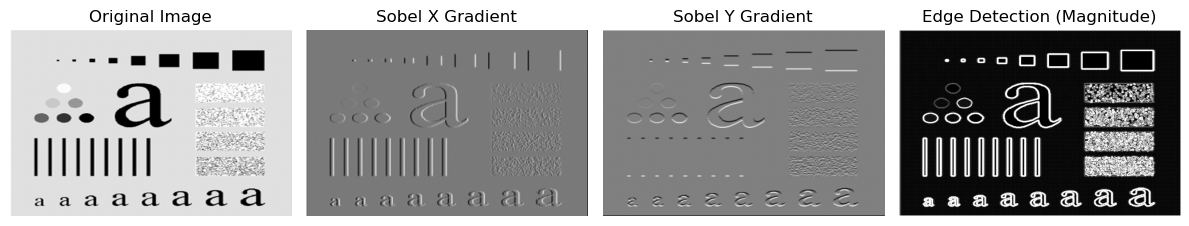

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_mask(image, mask):
    rows, cols = image.shape
    m_rows, m_cols = mask.shape
    pad_r, pad_c = m_rows // 2, m_cols // 2

    padded = np.zeros((rows + 2 * pad_r, cols + 2 * pad_c))
    padded[pad_r:pad_r + rows, pad_c:pad_c + cols] = image

    output = np.zeros_like(image)

    for i in range(rows):
        for j in range(cols):
            window = padded[i:i + m_rows, j:j + m_cols]
            output[i, j] = np.sum(window * mask)

    return output

def compute_gradient_magnitude(gx, gy):
    return np.sqrt(gx**2 + gy**2)

def main():
    image = cv2.imread('D:\\Code\\test_img.png', cv2.IMREAD_GRAYSCALE).astype(np.float32)

    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

    gx = apply_mask(image, sobel_x)
    gy = apply_mask(image, sobel_y)

    gradient_mag = compute_gradient_magnitude(gx, gy)

    gradient_mag = np.clip(gradient_mag, 0, 255)

    plt.figure(figsize=(12, 8))

    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(gx, cmap='gray')
    plt.title("Sobel X Gradient")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(gy, cmap='gray')
    plt.title("Sobel Y Gradient")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(gradient_mag, cmap='gray')
    plt.title("Edge Detection (Magnitude)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

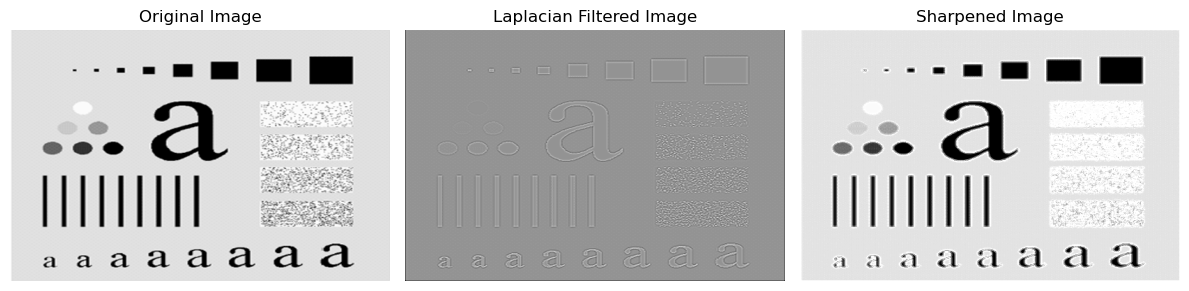

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_mask(image, mask):
    rows, cols = image.shape
    m_rows, m_cols = mask.shape
    pad_r, pad_c = m_rows // 2, m_cols // 2

    padded = np.zeros((rows + 2 * pad_r, cols + 2 * pad_c))
    padded[pad_r:pad_r + rows, pad_c:pad_c + cols] = image

    output = np.zeros_like(image)

    for i in range(rows):
        for j in range(cols):
            window = padded[i:i + m_rows, j:j + m_cols]
            output[i, j] = np.sum(window * mask)

    return output

def main():
    image = cv2.imread('D:\\Code\\test_img.png', cv2.IMREAD_GRAYSCALE).astype(np.float32)

    laplacian_mask = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])

    laplacian_image = apply_mask(image, laplacian_mask)
    laplacian_abs = np.abs(laplacian_image)
    sharpened_image = image + laplacian_abs
    sharpened_image = np.clip(sharpened_image, 0, 255)
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(laplacian_image, cmap='gray')
    plt.title('Laplacian Filtered Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(sharpened_image, cmap='gray')
    plt.title('Sharpened Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

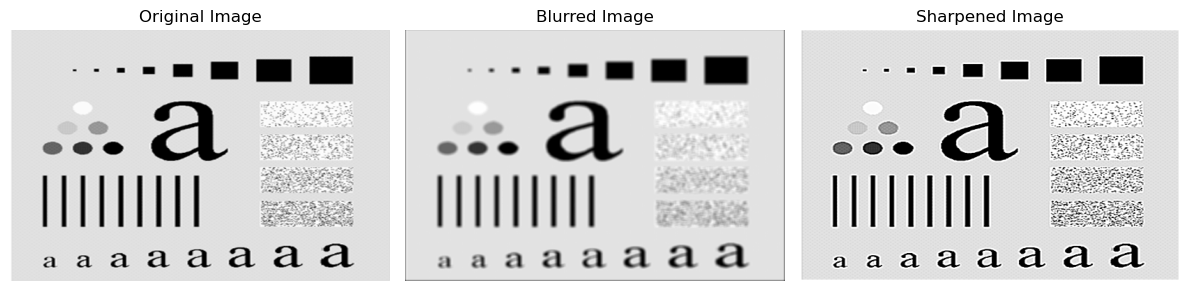

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_averaging_filter(image, size):
    pad = size // 2
    rows, cols = image.shape

    padded = np.zeros((rows + 2 * pad, cols + 2 * pad))
    padded[pad:pad + rows, pad:pad + cols] = image

    output = np.zeros_like(image)

    for i in range(rows):
        for j in range(cols):
            window = padded[i:i + size, j:j + size]
            output[i, j] = np.sum(window) / (size * size)

    return output

def unsharp_masking(image, blurred, alpha=1.5):
    mask = image - blurred
    sharpened = image + alpha * mask
    return np.clip(sharpened, 0, 255)

def main():
    image = cv2.imread("D:\\Code\\test_img.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)
    blurred = apply_averaging_filter(image, 5)
    sharpened = unsharp_masking(image, blurred, alpha=1.5)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(blurred, cmap='gray')
    plt.title("Blurred Image")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Sharpened Image")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()